In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = Path("../data/processed/job_postings_features.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head())

Shape: (17880, 72)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2    Unknown          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4    Unknown          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         de

In [2]:
X = df.drop(columns=["job_id", "fraudulent"])
y = df["fraudulent"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (17880, 70)
y shape: (17880,)

Target distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [5]:
job_text = (
    df[text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
    .str.strip()
)

In [6]:
job_groups = job_text.groupby(job_text).ngroup()

In [7]:
unique_groups = job_groups.unique()

In [8]:
train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.2,
    random_state=42
)


In [9]:
train_mask = job_groups.isin(train_groups)
test_mask = job_groups.isin(test_groups)

In [10]:
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

In [11]:
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14055, 70)
X_test: (3825, 70)
y_train: (14055,)
y_test: (3825,)


In [13]:
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training target distribution:
fraudulent
0    13379
1      676
Name: count, dtype: int64

Testing target distribution:
fraudulent
0    3635
1     190
Name: count, dtype: int64


In [14]:
train_texts = set(job_text[train_mask])
test_texts = set(job_text[test_mask])

print("Duplicate texts in both sets:", len(train_texts & test_texts))

Duplicate texts in both sets: 0


In [15]:
X_train_model = X_train.copy()
X_test_model = X_test.copy()

In [16]:
X_train_model["combined_text"] = job_text.loc[X_train.index]
X_test_model["combined_text"] = job_text.loc[X_test.index]


In [17]:
print("Training data:", X_train_model.shape)
print("Testing data:", X_test_model.shape)

Training data: (14055, 71)
Testing data: (3825, 71)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [19]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [20]:
categorical_columns = [
    "location",
    "department",
    "salary_range",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

In [21]:
excluded_columns = text_columns + ["combined_text"] + categorical_columns

numeric_columns = [
    col for col in X_train_model.columns
    if col not in excluded_columns
]


In [22]:
text_transformer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [23]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, "combined_text"),
        ("cat", categorical_transformer, categorical_columns),
        ("num", numeric_transformer, numeric_columns)
    ],
    remainder="drop"
)

In [26]:
print("Preprocessing pipeline created.")
print("Categorical features:", len(categorical_columns))
print("Numerical features:", len(numeric_columns))

Preprocessing pipeline created.
Categorical features: 8
Numerical features: 57


In [27]:
X_train_processed = preprocessor.fit_transform(X_train_model)
X_test_processed = preprocessor.transform(X_test_model)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Training matrix type:", type(X_train_processed))

Processed training shape: (14055, 34793)
Processed testing shape: (3825, 34793)
Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

In [30]:
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    ))


Training Logistic Regression...


C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

     Genuine       0.98      0.62      0.76      3635
  Fraudulent       0.10      0.76      0.17       190

    accuracy                           0.63      3825
   macro avg       0.54      0.69      0.46      3825
weighted avg       0.94      0.63      0.73      3825


Training Multinomial Naive Bayes...
              precision    recall  f1-score   support

     Genuine       0.96      0.94      0.95      3635
  Fraudulent       0.11      0.16      0.13       190

    accuracy                           0.90      3825
   macro avg       0.53      0.55      0.54      3825
weighted avg       0.91      0.90      0.90      3825


Training Linear SVM...
              precision    recall  f1-score   support

     Genuine       0.97      0.74      0.84      3635
  Fraudulent       0.10      0.53      0.17       190

    accuracy                           0.73      3825
   macro avg       0.53      0.64      0.50      3825
weighted avg 

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [31]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\nBaseline Model Comparison:")
print(results_df.round(4).to_string(index=False))


Baseline Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score
    Logistic Regression    0.6272     0.0950  0.7632    0.1690
             Linear SVM    0.7336     0.0980  0.5316    0.1654
Multinomial Naive Bayes    0.8967     0.1132  0.1579    0.1319


In [33]:
y_prob_lr = models["Logistic Regression"].predict_proba(
    X_test_processed
)[:, 1]


In [34]:
threshold = 0.7
y_pred_threshold = (y_prob_lr >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_threshold,
    target_names=["Genuine", "Fraudulent"],
    zero_division=0
))


Confusion Matrix:
[[3453  182]
 [ 130   60]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.96      0.95      0.96      3635
  Fraudulent       0.25      0.32      0.28       190

    accuracy                           0.92      3825
   macro avg       0.61      0.63      0.62      3825
weighted avg       0.93      0.92      0.92      3825



In [35]:
print("Fraud Precision:", round(
    precision_score(y_test, y_pred_threshold, zero_division=0), 4
))
print("Fraud Recall:", round(
    recall_score(y_test, y_pred_threshold, zero_division=0), 4
))
print("Fraud F1 Score:", round(
    f1_score(y_test, y_pred_threshold, zero_division=0), 4
))

Fraud Precision: 0.2479
Fraud Recall: 0.3158
Fraud F1 Score: 0.2778


In [36]:
# Get the combined text for the current training set
train_job_text = job_text.loc[X_train.index]

# Group identical job postings
train_groups = train_job_text.groupby(train_job_text).ngroup()

unique_train_groups = train_groups.unique()

# Split groups into training and validation groups
fit_groups, val_groups = train_test_split(
    unique_train_groups,
    test_size=0.2,
    random_state=42
)

In [37]:
fit_mask = train_groups.isin(fit_groups)
val_mask = train_groups.isin(val_groups)

X_fit = X_train.loc[fit_mask].copy()
X_val = X_train.loc[val_mask].copy()

y_fit = y_train.loc[fit_mask].copy()
y_val = y_train.loc[val_mask].copy()

print("Training set:", X_fit.shape)
print("Validation set:", X_val.shape)
print("Training fraud counts:")
print(y_fit.value_counts())

Training set: (11279, 70)
Validation set: (2776, 70)
Training fraud counts:
fraudulent
0    10723
1      556
Name: count, dtype: int64


In [38]:
print("\nValidation fraud counts:")
print(y_val.value_counts())

# Verify no duplicate postings cross the split
fit_texts = set(train_job_text.loc[fit_mask])
val_texts = set(train_job_text.loc[val_mask])

print("\nDuplicate texts across fit and validation:", len(fit_texts & val_texts))


Validation fraud counts:
fraudulent
0    2656
1     120
Name: count, dtype: int64

Duplicate texts across fit and validation: 0


In [39]:
# Fit preprocessing only on the fit subset
X_fit_model = X_fit.copy()
X_val_model = X_val.copy()

X_fit_model["combined_text"] = job_text.loc[X_fit.index]
X_val_model["combined_text"] = job_text.loc[X_val.index]

# Fit using fit data only
X_fit_processed = preprocessor.fit_transform(X_fit_model)

# Transform validation data without fitting again
X_val_processed = preprocessor.transform(X_val_model)

print("Processed fit shape:", X_fit_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Preprocessing fitted on fit data only.")

Processed fit shape: (11279, 34219)
Processed validation shape: (2776, 34219)
Preprocessing fitted on fit data only.


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


In [41]:
lr_validation_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [42]:
lr_validation_model.fit(X_fit_processed, y_fit)

# Get fraud probabilities on validation data
y_val_prob = lr_validation_model.predict_proba(
    X_val_processed
)[:, 1]

# Evaluate candidate thresholds
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

In [44]:
threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.round(4).to_string(index=False)
)

best_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print("\nBest threshold by validation F1:", best_threshold)
print(best_row)

 Threshold  Precision  Recall  F1 Score
      0.10     0.0478  0.9917    0.0911
      0.15     0.0509  0.9917    0.0968
      0.20     0.0518  0.9417    0.0983
      0.25     0.0561  0.9333    0.1058
      0.30     0.0612  0.9167    0.1148
      0.35     0.0687  0.9000    0.1277
      0.40     0.0746  0.8417    0.1371
      0.45     0.0872  0.8250    0.1578
      0.50     0.1001  0.7833    0.1775
      0.55     0.1105  0.6917    0.1906
      0.60     0.1190  0.5417    0.1952
      0.65     0.1285  0.4250    0.1973
      0.70     0.1330  0.2583    0.1756
      0.75     0.1429  0.1333    0.1379
      0.80     0.1493  0.0833    0.1070
      0.85     0.1111  0.0250    0.0408
      0.90     0.1250  0.0167    0.0294

Best threshold by validation F1: 0.65
Threshold    0.650000
Precision    0.128463
Recall       0.425000
F1 Score     0.197292
Name: 11, dtype: float64


In [45]:
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

extra_models = {
    "SGD Classifier": SGDClassifier(
        loss="hinge",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Complement Naive Bayes": ComplementNB()
}

extra_results = []

for name, model in extra_models.items():
    print(f"Training {name}...")

    model.fit(X_fit_processed, y_fit)
    y_val_pred = model.predict(X_val_processed)

    extra_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

extra_results_df = pd.DataFrame(extra_results)

print("\nAdditional Model Results:")
print(extra_results_df.round(4).to_string(index=False))

Training SGD Classifier...
Training Complement Naive Bayes...

Additional Model Results:
                 Model  Accuracy  Precision  Recall  F1 Score
        SGD Classifier    0.1261     0.0432  0.9083    0.0825
Complement Naive Bayes    0.8548     0.0969  0.2833    0.1444


In [46]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

validation_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "SGD Classifier": SGDClassifier(
        loss="hinge",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Complement Naive Bayes": ComplementNB()
}

validation_results = []

for name, model in validation_models.items():
    print(f"Training {name}...")

    model.fit(X_fit_processed, y_fit)
    predictions = model.predict(X_val_processed)

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, predictions, zero_division=0
        )
    })

validation_results_df = pd.DataFrame(validation_results)

validation_results_df = validation_results_df.sort_values(
    "F1 Score", ascending=False
)

print("\nValidation Model Comparison:")
print(validation_results_df.round(4).to_string(index=False))

Training Logistic Regression...


C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Linear SVM...


C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training Multinomial Naive Bayes...
Training SGD Classifier...
Training Complement Naive Bayes...

Validation Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score
    Logistic Regression    0.6862     0.1001  0.7833    0.1775
             Linear SVM    0.5774     0.0791  0.8250    0.1444
Multinomial Naive Bayes    0.8548     0.0969  0.2833    0.1444
 Complement Naive Bayes    0.8548     0.0969  0.2833    0.1444
         SGD Classifier    0.1261     0.0432  0.9083    0.0825


In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Remove raw text and combined text
structured_columns = [
    col for col in X_fit.columns
    if col not in text_columns
]

print("Number of structured features:", len(structured_columns))
print("Structured features:")
print(structured_columns)

Number of structured features: 65
Structured features:
['location', 'department', 'salary_range', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'has_department', 'has_salary_range', 'has_company_profile', 'has_description', 'has_requirements', 'has_benefits', 'has_employment_type', 'has_required_experience', 'has_required_education', 'has_industry', 'has_function', 'title_char_length', 'title_word_count', 'company_profile_char_length', 'company_profile_word_count', 'description_char_length', 'description_word_count', 'requirements_char_length', 'requirements_word_count', 'benefits_char_length', 'benefits_word_count', 'salary_min', 'salary_max', 'salary_is_range', 'salary_midpoint', 'salary_range_width', 'has_location', 'is_remote', 'is_hybrid', 'skill_count', 'has_technical_skills', 'has_python', 'has_ml_skill', 'has_data_skill', 'is_entry_level', 'is_associate', 'is_mid_senior', 'is_executi

In [49]:
X_fit_structured = X_fit[structured_columns].copy()
X_val_structured = X_val[structured_columns].copy()

categorical_cols = X_fit_structured.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = [
    col for col in structured_columns
    if col not in categorical_cols
]

structured_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown"
                )),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="median"
                ))
            ]),
            numeric_cols
        )
    ]
)

random_forest_pipeline = Pipeline([
    ("preprocessor", structured_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

random_forest_pipeline.fit(X_fit_structured, y_fit)

rf_val_pred = random_forest_pipeline.predict(X_val_structured)

print("\nRandom Forest — Validation Results")
print("Accuracy:", round(
    accuracy_score(y_val, rf_val_pred), 4
))
print("Precision:", round(
    precision_score(y_val, rf_val_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_val, rf_val_pred, zero_division=0), 4
))
print("F1 Score:", round(
    f1_score(y_val, rf_val_pred, zero_division=0), 4
))


Random Forest — Validation Results
Accuracy: 0.9035
Precision: 0.2921
Recall: 0.8667
F1 Score: 0.437


True Negatives: 2404
False Positives: 252
False Negatives: 16
True Positives: 104


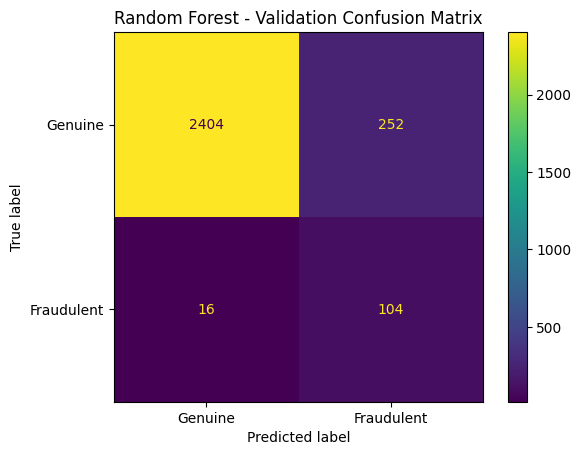

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_val, rf_val_pred)

tn, fp, fn, tp = rf_cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

display = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Genuine", "Fraudulent"]
)

display.plot()
plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

In [51]:
import pandas as pd

# Get the fitted preprocessing and Random Forest model
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
rf_model = random_forest_pipeline.named_steps["model"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance scores
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance", ascending=False
)

print("Top 20 Important Features:")
print(importance_df.head(20).to_string(index=False))

Top 20 Important Features:
                          Feature  Importance
  num__company_profile_word_count    0.083831
 num__company_profile_char_length    0.072024
         num__has_company_profile    0.057608
       num__short_company_profile    0.055573
            num__has_company_logo    0.051030
     num__requirements_word_count    0.024449
    num__requirements_char_length    0.023646
          num__text_section_count    0.023625
     num__description_char_length    0.020735
       cat__industry_Oil & Energy    0.019275
      num__description_word_count    0.018327
    cat__location_US, TX, Houston    0.015848
num__missing_important_info_count    0.015684
        num__benefits_char_length    0.015095
           num__title_char_length    0.014358
         num__benefits_word_count    0.013944
              num__is_high_school    0.013921
                 num__skill_count    0.013501
               num__has_questions    0.013105
                num__is_bachelors    0.011802


In [52]:
from pathlib import Path

output_dir = Path("../reports")
output_dir.mkdir(parents=True, exist_ok=True)

importance_path = output_dir / "random_forest_feature_importance.csv"

importance_df.head(20).to_csv(importance_path, index=False)

print("Saved:", importance_path)
print("Features saved:", min(20, len(importance_df)))

Saved: ..\reports\random_forest_feature_importance.csv
Features saved: 20


In [53]:
rf_val_prob = random_forest_pipeline.predict_proba(
    X_val_structured
)[:, 1]

# Test thresholds using validation data only
thresholds = np.arange(0.10, 0.91, 0.05)

rf_threshold_results = []

for threshold in thresholds:
    rf_threshold_pred = (
        rf_val_prob >= threshold
    ).astype(int)

    rf_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val, rf_threshold_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, rf_threshold_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, rf_threshold_pred, zero_division=0
        )
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

print(rf_threshold_df.round(4).to_string(index=False))

best_rf_row = rf_threshold_df.loc[
    rf_threshold_df["F1 Score"].idxmax()
]

best_rf_threshold = best_rf_row["Threshold"]

print("\nBest Random Forest threshold:", best_rf_threshold)
print(best_rf_row)

 Threshold  Precision  Recall  F1 Score
      0.10     0.0470  1.0000    0.0898
      0.15     0.0624  1.0000    0.1174
      0.20     0.0973  0.9917    0.1772
      0.25     0.1425  0.9833    0.2489
      0.30     0.1810  0.9833    0.3057
      0.35     0.2136  0.9667    0.3499
      0.40     0.2391  0.9167    0.3793
      0.45     0.2683  0.9167    0.4151
      0.50     0.2921  0.8667    0.4370
      0.55     0.3414  0.8250    0.4829
      0.60     0.4035  0.7667    0.5287
      0.65     0.4602  0.6750    0.5473
      0.70     0.5840  0.6083    0.5959
      0.75     0.7969  0.4250    0.5543
      0.80     0.9706  0.2750    0.4286
      0.85     1.0000  0.1500    0.2609
      0.90     1.0000  0.0083    0.0165

Best Random Forest threshold: 0.7
Threshold    0.700000
Precision    0.584000
Recall       0.608333
F1 Score     0.595918
Name: 12, dtype: float64


In [54]:
rf_threshold_summary = pd.DataFrame([{
    "Model": "Random Forest",
    "Selected Threshold": best_rf_threshold,
    "Validation Precision": best_rf_row["Precision"],
    "Validation Recall": best_rf_row["Recall"],
    "Validation F1 Score": best_rf_row["F1 Score"]
}])

summary_path = Path("../reports/random_forest_threshold_results.csv")
summary_path.parent.mkdir(parents=True, exist_ok=True)

rf_threshold_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
print(rf_threshold_summary.round(4).to_string(index=False))

Saved: ..\reports\random_forest_threshold_results.csv
        Model  Selected Threshold  Validation Precision  Validation Recall  Validation F1 Score
Random Forest                 0.7                 0.584             0.6083               0.5959


Final Threshold: 0.7
Test Accuracy: 0.9647
Fraud Precision: 0.6608
Fraud Recall: 0.5947
Fraud F1 Score: 0.626

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.98      0.98      0.98      3635
  Fraudulent       0.66      0.59      0.63       190

    accuracy                           0.96      3825
   macro avg       0.82      0.79      0.80      3825
weighted avg       0.96      0.96      0.96      3825

True Negatives: 3577
False Positives: 58
False Negatives: 77
True Positives: 113


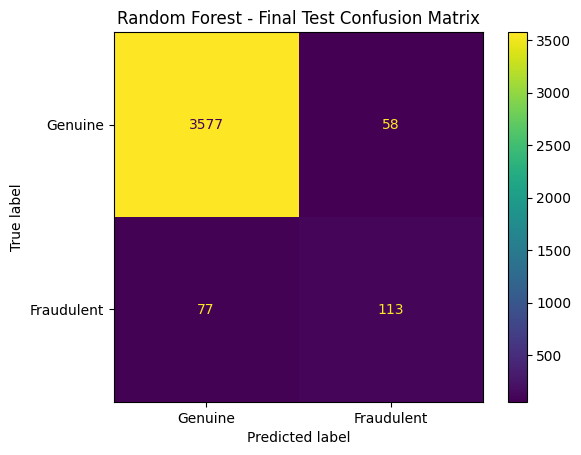

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Use the existing structured test features
X_test_structured = X_test[structured_columns].copy()

# Predict fraud probabilities with the fitted Random Forest
rf_test_prob = random_forest_pipeline.predict_proba(
    X_test_structured
)[:, 1]

# Apply the threshold selected using validation data
final_threshold = best_rf_threshold
rf_test_pred = (rf_test_prob >= final_threshold).astype(int)

# Evaluate on the untouched test set
print("Final Threshold:", final_threshold)
print("Test Accuracy:", round(
    accuracy_score(y_test, rf_test_pred), 4
))
print("Fraud Precision:", round(
    precision_score(y_test, rf_test_pred, zero_division=0), 4
))
print("Fraud Recall:", round(
    recall_score(y_test, rf_test_pred, zero_division=0), 4
))
print("Fraud F1 Score:", round(
    f1_score(y_test, rf_test_pred, zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_test_pred,
    target_names=["Genuine", "Fraudulent"],
    zero_division=0
))

# Confusion matrix
cm_test = confusion_matrix(y_test, rf_test_pred)
tn, fp, fn, tp = cm_test.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Genuine", "Fraudulent"]
)
display.plot()
plt.title("Random Forest - Final Test Confusion Matrix")
plt.show()

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# Build a fresh pipeline for tuning
rf_tuning_pipeline = Pipeline([
    ("preprocessor", structured_preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Parameters to explore
param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

# Stratified CV preserves class proportions across folds
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True
)

# Search only on the fit subset
random_search.fit(X_fit_structured, y_fit)

print("Best CV F1:", round(random_search.best_score_, 4))
print("\nBest parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV F1: 0.6903

Best parameters:
{'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 7, 'model__n_estimators': 300}


In [57]:
# Best tuned pipeline
best_rf_model = random_search.best_estimator_

# Predict validation labels at default threshold
tuned_val_pred = best_rf_model.predict(X_val_structured)

print("Tuned Random Forest — Validation Results")
print("Accuracy:", round(
    accuracy_score(y_val, tuned_val_pred), 4
))
print("Precision:", round(
    precision_score(y_val, tuned_val_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_val, tuned_val_pred, zero_division=0), 4
))
print("F1 Score:", round(
    f1_score(y_val, tuned_val_pred, zero_division=0), 4
))


Tuned Random Forest — Validation Results
Accuracy: 0.9705
Precision: 0.6484
Recall: 0.6917
F1 Score: 0.6694


In [58]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, tuned_val_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    tuned_val_pred,
    target_names=["Genuine", "Fraudulent"],
    zero_division=0
))


Confusion Matrix:
[[2611   45]
 [  37   83]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.98      0.98      2656
  Fraudulent       0.65      0.69      0.67       120

    accuracy                           0.97      2776
   macro avg       0.82      0.84      0.83      2776
weighted avg       0.97      0.97      0.97      2776



In [59]:
tuned_val_prob = best_rf_model.predict_proba(
    X_val_structured
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)
tuned_threshold_results = []

for threshold in thresholds:
    predictions = (tuned_val_prob >= threshold).astype(int)

    tuned_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, predictions, zero_division=0
        )
    })

tuned_threshold_df = pd.DataFrame(tuned_threshold_results)

print(tuned_threshold_df.round(4).to_string(index=False))

best_tuned_row = tuned_threshold_df.loc[
    tuned_threshold_df["F1 Score"].idxmax()
]

best_tuned_threshold = best_tuned_row["Threshold"]

print("\nBest tuned-model threshold:", best_tuned_threshold)
print(best_tuned_row)

 Threshold  Precision  Recall  F1 Score
      0.10     0.2517  0.9083    0.3942
      0.15     0.3129  0.8917    0.4632
      0.20     0.3788  0.8333    0.5208
      0.25     0.4163  0.8083    0.5496
      0.30     0.4798  0.7917    0.5975
      0.35     0.5205  0.7417    0.6117
      0.40     0.5686  0.7250    0.6374
      0.45     0.6194  0.6917    0.6535
      0.50     0.6484  0.6917    0.6694
      0.55     0.6583  0.6583    0.6583
      0.60     0.6789  0.6167    0.6463
      0.65     0.6961  0.5917    0.6396
      0.70     0.7419  0.5750    0.6479
      0.75     0.7654  0.5167    0.6169
      0.80     0.8095  0.4250    0.5574
      0.85     0.9130  0.3500    0.5060
      0.90     1.0000  0.2500    0.4000

Best tuned-model threshold: 0.5
Threshold    0.500000
Precision    0.648438
Recall       0.691667
F1 Score     0.669355
Name: 8, dtype: float64


In [60]:
tuned_test_prob = best_rf_model.predict_proba(
    X_test_structured
)[:, 1]

# Apply the threshold selected on validation data
tuned_test_pred = (
    tuned_test_prob >= best_tuned_threshold
).astype(int)

print("Selected threshold:", best_tuned_threshold)
print("Test Accuracy:", round(
    accuracy_score(y_test, tuned_test_pred), 4
))
print("Test Precision:", round(
    precision_score(y_test, tuned_test_pred, zero_division=0), 4
))
print("Test Recall:", round(
    recall_score(y_test, tuned_test_pred, zero_division=0), 4
))
print("Test F1 Score:", round(
    f1_score(y_test, tuned_test_pred, zero_division=0), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_test_pred,
    target_names=["Genuine", "Fraudulent"],
    zero_division=0
))

Selected threshold: 0.5
Test Accuracy: 0.971
Test Precision: 0.7135
Test Recall: 0.6947
Test F1 Score: 0.704

Confusion Matrix:
[[3582   53]
 [  58  132]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.98      0.99      0.98      3635
  Fraudulent       0.71      0.69      0.70       190

    accuracy                           0.97      3825
   macro avg       0.85      0.84      0.84      3825
weighted avg       0.97      0.97      0.97      3825



In [61]:
tuned_test_prob = best_rf_model.predict_proba(
    X_test_structured
)[:, 1]

# Apply the threshold selected using validation data
tuned_test_pred = (
    tuned_test_prob >= best_tuned_threshold
).astype(int)

print("Selected Threshold:", best_tuned_threshold)

print("Accuracy:", accuracy_score(y_test, tuned_test_pred))
print("Precision:", precision_score(y_test, tuned_test_pred, zero_division=0))
print("Recall:", recall_score(y_test, tuned_test_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, tuned_test_pred, zero_division=0))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_test_pred,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_test_pred))

Selected Threshold: 0.5
Accuracy: 0.9709803921568627
Precision: 0.7135135135135136
Recall: 0.6947368421052632
F1 Score: 0.704

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.98      0.99      0.98      3635
  Fraudulent       0.71      0.69      0.70       190

    accuracy                           0.97      3825
   macro avg       0.85      0.84      0.84      3825
weighted avg       0.97      0.97      0.97      3825


Confusion Matrix:
[[3582   53]
 [  58  132]]


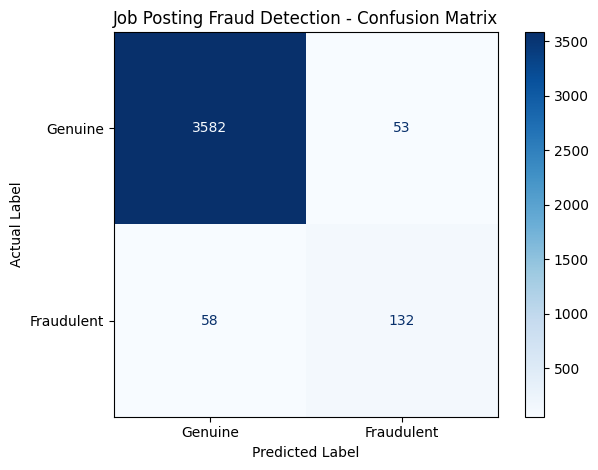

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_test_pred,
    display_labels=["Genuine", "Fraudulent"],
    values_format="d",
    cmap="Blues"
)

plt.title("Job Posting Fraud Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


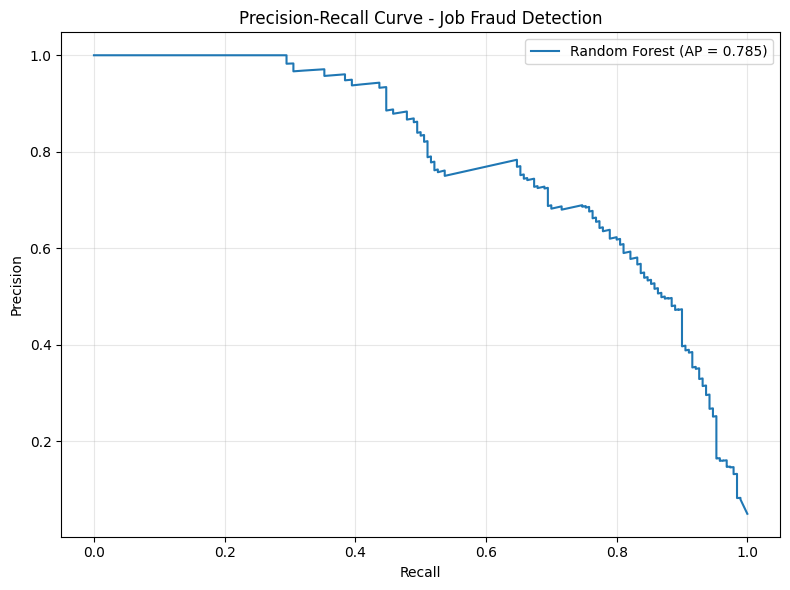

Average Precision: 0.7852


In [65]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    tuned_test_prob
)

# Calculate Average Precision
avg_precision = average_precision_score(
    y_test,
    tuned_test_prob
)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {avg_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Job Fraud Detection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Precision:", round(avg_precision, 4))

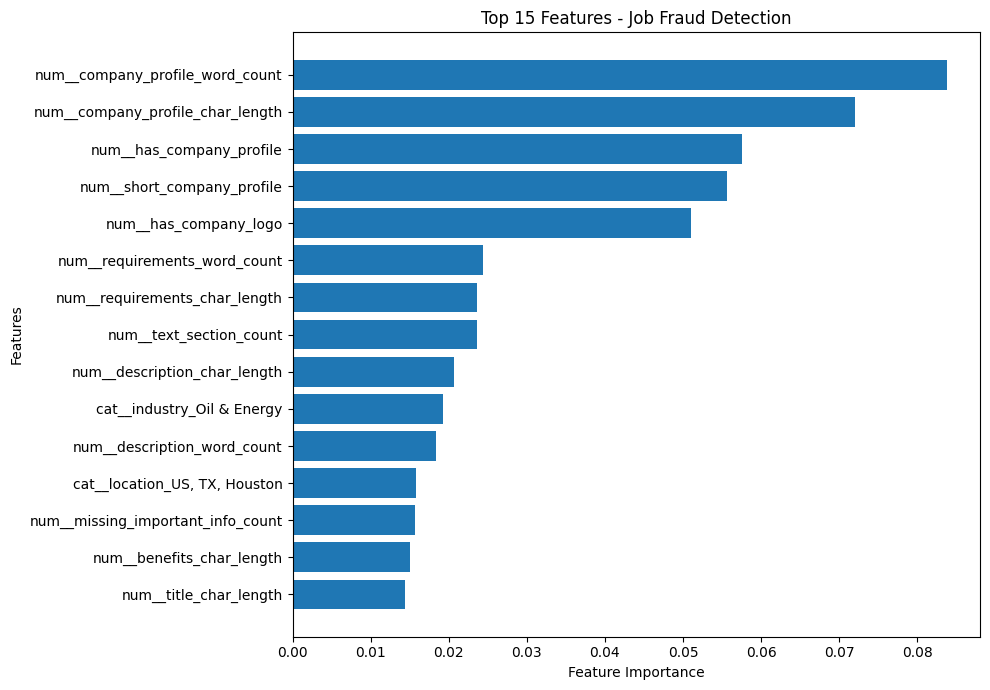

In [68]:
import matplotlib.pyplot as plt

# Select the top 15 features
top_features = importance_df.nlargest(
    15, "Importance"
).sort_values(
    by="Importance",
    ascending=True
)

# Plot the graph
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Features - Job Fraud Detection")

plt.tight_layout()
plt.show()

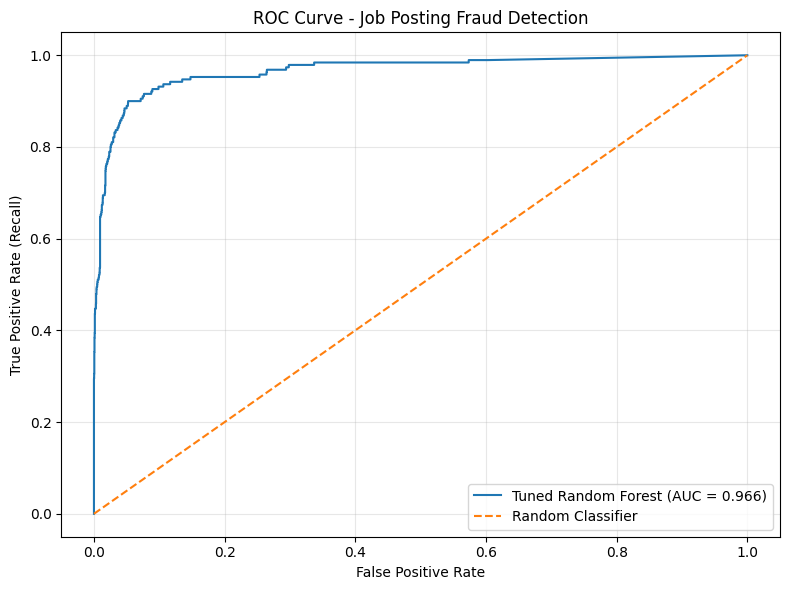

ROC-AUC Score: 0.9661


In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve using test probabilities
fpr, tpr, thresholds = roc_curve(
    y_test,
    tuned_test_prob
)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(
    y_test,
    tuned_test_prob
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Tuned Random Forest (AUC = {roc_auc:.3f})"
)

# Random guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Job Posting Fraud Detection")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", round(roc_auc, 4))

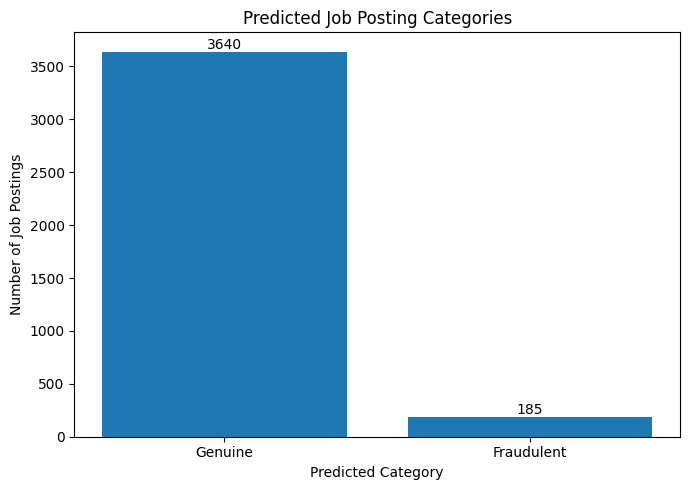

Genuine       3640
Fraudulent     185
Name: count, dtype: int64


In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# Count predicted classes
prediction_counts = pd.Series(
    tuned_test_pred
).map({
    0: "Genuine",
    1: "Fraudulent"
}).value_counts().reindex(
    ["Genuine", "Fraudulent"],
    fill_value=0
)

# Plot bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    prediction_counts.index,
    prediction_counts.values
)

plt.title("Predicted Job Posting Categories")
plt.xlabel("Predicted Category")
plt.ylabel("Number of Job Postings")

# Display counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print(prediction_counts)

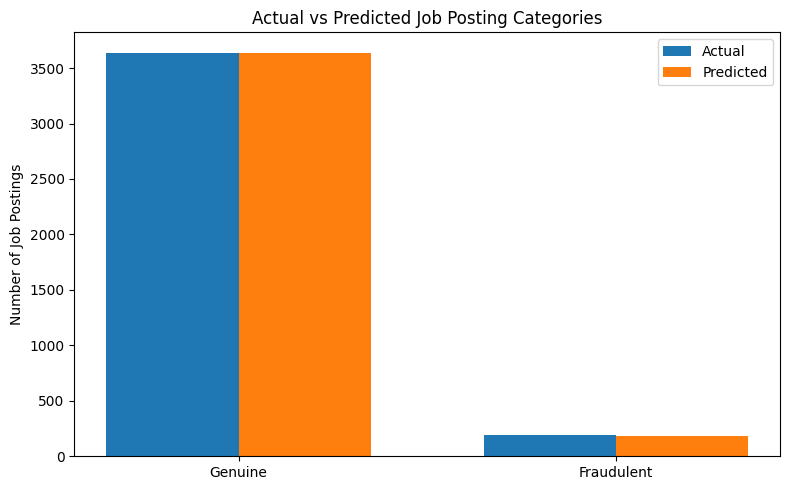

Actual counts: [3635  190]
Predicted counts: [3640  185]


In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Count actual and predicted classes
actual_counts = np.bincount(y_test.astype(int), minlength=2)
predicted_counts = np.bincount(tuned_test_pred, minlength=2)

labels = ["Genuine", "Fraudulent"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    actual_counts,
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted"
)

plt.xticks(x, labels)
plt.ylabel("Number of Job Postings")
plt.title("Actual vs Predicted Job Posting Categories")
plt.legend()
plt.tight_layout()
plt.show()

print("Actual counts:", actual_counts)
print("Predicted counts:", predicted_counts)

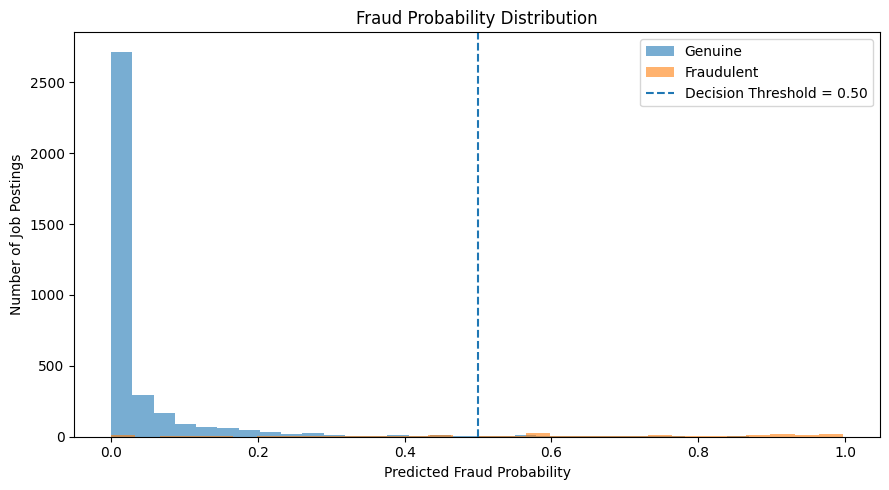

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    tuned_test_prob[y_test.to_numpy() == 0]
    if hasattr(y_test, "to_numpy")
    else tuned_test_prob[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    tuned_test_prob[y_test.to_numpy() == 1]
    if hasattr(y_test, "to_numpy")
    else tuned_test_prob[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Fraudulent"
)

plt.axvline(
    best_tuned_threshold,
    linestyle="--",
    label=f"Decision Threshold = {best_tuned_threshold:.2f}"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Job Postings")
plt.title("Fraud Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
from pathlib import Path

results_dir = Path("../reports")
results_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    results_dir / "fraud_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print(
    (results_dir / "fraud_probability_distribution.png").exists()
)